# Ride-Share Surge Pricing Analysis  
**Data → Decision Series | Week 1 – Case 2**

## Objective
Evaluate whether **time patterns** or **weather conditions** show a stronger relationship with ride-share **surge pricing**.

## Dataset
- Uber & Lyft trip dataset (high-frequency ride estimates)
- Hourly weather dataset
- Coverage: ~3 weeks, single city (Boston-area locations)


## 1) Imports & Data Loading


In [0]:
pip install plotly

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

import plotly.express as px

cab=pd.read_csv("/Workspace/Users/0kirtirms@gmail.com/Week1_Car_price_analysis/cab_rides.csv")
weather=pd.read_csv("/Workspace/Users/0kirtirms@gmail.com/Week1_Car_price_analysis/weather.csv")

## 2) Quick Data Inspection (Minimal)


In [0]:
cab.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [0]:
cab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  int64  
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  float64
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


In [0]:
cab.describe()

,distance,time_stamp,price,surge_multiplier
count,693071.000000,6.930710e+05,637976.000000,693071.000000
mean,2.189430,1.544046e+12,16.545125,1.013870
std,1.138937,6.891925e+08,9.324359,0.091641
min,0.020000,1.543204e+12,2.500000,1.000000
25%,1.280000,1.543444e+12,9.000000,1.000000
50%,2.160000,1.543737e+12,13.500000,1.000000
75%,2.920000,1.544828e+12,22.500000,1.000000
max,7.860000,1.545161e+12,97.500000,3.000000


In [0]:
weather.head()

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49


In [0]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp        6276 non-null   float64
 1   location    6276 non-null   object 
 2   clouds      6276 non-null   float64
 3   pressure    6276 non-null   float64
 4   rain        894 non-null    float64
 5   time_stamp  6276 non-null   int64  
 6   humidity    6276 non-null   float64
 7   wind        6276 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 392.4+ KB


In [0]:
weather.describe()

,temp,clouds,pressure,rain,time_stamp,humidity,wind
count,6276.000000,6276.000000,6276.000000,894.000000,6.276000e+03,6276.000000,6276.000000
mean,39.090475,0.677777,1008.445209,0.057652,1.543857e+09,0.763985,6.802812
std,6.022055,0.314284,12.870775,0.100758,6.659340e+05,0.127340,3.633466
min,19.620000,0.000000,988.250000,0.000200,1.543204e+09,0.450000,0.290000
25%,36.077500,0.440000,997.747500,0.004900,1.543387e+09,0.670000,3.517500
50%,40.130000,0.780000,1007.660000,0.014850,1.543514e+09,0.760000,6.570000
75%,42.832500,0.970000,1018.480000,0.060925,1.544691e+09,0.890000,9.920000
max,55.410000,1.000000,1035.120000,0.780700,1.545159e+09,0.990000,18.180000


## 3) Cleaning Cab Data
- Drop rides with missing price (cannot analyze cost/surge without price)
- Drop ID columns not needed for analysis
- Convert UNIX timestamp (milliseconds) to datetime


In [0]:
#null percentage for price column
percent=cab['price'].isnull().sum()/cab.shape[0]*100
print("Percentage of null values in price column is: ",percent)

Percentage of null values in price column is:  7.949402009317949


In [0]:
#dropping the null values 
cab=cab.dropna(subset=['price'])

In [0]:
#also dropping unnecessary columns
cab=cab.drop(['id','product_id'], axis=1)
cab.columns

Index(['distance', 'cab_type', 'time_stamp', 'destination', 'source', 'price',
       'surge_multiplier', 'name'],
      dtype='object')

In [0]:
#timestamp is in int which means its in unix format so converting unix time 
cab['time_stamp']=pd.to_datetime(cab['time_stamp'], unit='ms')
cab['time_stamp'].head()

0   2018-12-16 09:30:07.890
1   2018-11-27 02:00:23.677
2   2018-11-28 01:00:22.198
3   2018-11-30 04:53:02.749
4   2018-11-29 03:49:20.223
Name: time_stamp, dtype: datetime64[ns]

## 4) Cleaning Weather Data
- Rain is sparse: fill missing rain with 0
- Create a boolean flag `is_Raining`
- Convert UNIX timestamp (seconds) to datetime


In [0]:
#checking missing percent 
percent2=weather['rain'].isnull().sum()/weather.shape[0]*100
print("Percent of null values for rain",percent2)

Percent of null values for rain 85.75525812619503


In [0]:
#since raining chances is usually very low we can make it a boolean and fill it 0 if no rain and 1 if rain
weather['rain']=weather['rain'].fillna(0)
weather['is_Raining']=weather['rain']>0
weather.head()

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind,is_Raining
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25,True
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32,True
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07,True
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09,True
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49,True


In [0]:
#converting time stamp even for weather data
weather['time_stamp']=pd.to_datetime(weather['time_stamp'], unit='s')
weather['time_stamp'].head()

0   2018-12-16 23:45:01
1   2018-12-16 23:45:01
2   2018-12-16 23:45:01
3   2018-12-16 23:45:01
4   2018-12-16 23:45:01
Name: time_stamp, dtype: datetime64[ns]

In [0]:
cab['time_stamp'].min(),cab['time_stamp'].max()
weather['time_stamp'].min(),weather['time_stamp'].max()

(Timestamp('2018-11-26 03:40:44'), Timestamp('2018-12-18 18:45:02'))

## 5) Merge Trips + Weather (Hourly Alignment)
Weather is hourly; trips are higher frequency.
We align both to `ts_hour` (hour bucket) before merging.


In [0]:
cab['ts_hour']=cab['time_stamp'].dt.floor('H')
weather['ts_hour']=weather['time_stamp'].dt.floor('H')
cab.head()

/home/spark-6ab178c0-80a5-46b5-bf71-f0/.ipykernel/3323/command-4808720323158423-2805594450:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  cab['ts_hour']=cab['time_stamp'].dt.floor('H')
/home/spark-6ab178c0-80a5-46b5-bf71-f0/.ipykernel/3323/command-4808720323158423-2805594450:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  weather['ts_hour']=weather['time_stamp'].dt.floor('H')


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,name,ts_hour
0,0.44,Lyft,2018-12-16 09:30:07.890,North Station,Haymarket Square,5.0,1.0,Shared,2018-12-16 09:00:00
1,0.44,Lyft,2018-11-27 02:00:23.677,North Station,Haymarket Square,11.0,1.0,Lux,2018-11-27 02:00:00
2,0.44,Lyft,2018-11-28 01:00:22.198,North Station,Haymarket Square,7.0,1.0,Lyft,2018-11-28 01:00:00
3,0.44,Lyft,2018-11-30 04:53:02.749,North Station,Haymarket Square,26.0,1.0,Lux Black XL,2018-11-30 04:00:00
4,0.44,Lyft,2018-11-29 03:49:20.223,North Station,Haymarket Square,9.0,1.0,Lyft XL,2018-11-29 03:00:00


In [0]:
df=cab.merge(
    weather,
    left_on=['ts_hour','source'],
    right_on=['ts_hour','location'],
    how='left'
)
print("Merged shape:", df.shape)
print("Weather missing % after merge:\n", df[['temp','humidity','wind','clouds','rain']].isna().mean().sort_values())
print("Time range:", df['ts_hour'].min(), "→", df['ts_hour'].max())


Merged shape: (1167730, 18)
Weather missing % after merge:
 temp        0.002341
humidity    0.002341
wind        0.002341
clouds      0.002341
rain        0.002341
dtype: float64
Time range: 2018-11-26 03:00:00 → 2018-12-18 19:00:00


## 6) Feature Engineering + Post-Merge Cleanup
Create time features and fix any merge-induced nulls.


In [0]:
#creating time features
df['hour']=df['ts_hour'].dt.hour
df['weekday']=df['ts_hour'].dt.day_name()
df['is_weekend']=df['weekday'].isin(['Saturday','Sunday'])
df['is_peak']=df['hour'].isin([7,8,9,16,17,18])
df.head()

,distance,cab_type,time_stamp_x,destination,source,price,surge_multiplier,name,ts_hour,temp,location,clouds,pressure,rain,time_stamp_y,humidity,wind,is_Raining,hour,weekday,is_weekend,is_peak
0,0.44,Lyft,2018-12-16 09:30:07.890,North Station,Haymarket Square,5.0,1.0,Shared,2018-12-16 09:00:00,38.46,Haymarket Square,0.29,1022.25,0.0000,2018-12-16 09:45:01,0.76,7.68,False,9,Sunday,True,True
1,0.44,Lyft,2018-11-27 02:00:23.677,North Station,Haymarket Square,11.0,1.0,Lux,2018-11-27 02:00:00,44.31,Haymarket Square,1.00,1003.17,0.1123,2018-11-27 02:15:20,0.90,13.69,True,2,Tuesday,False,False
2,0.44,Lyft,2018-11-27 02:00:23.677,North Station,Haymarket Square,11.0,1.0,Lux,2018-11-27 02:00:00,43.82,Haymarket Square,0.99,1002.59,0.0997,2018-11-27 02:45:20,0.89,11.57,True,2,Tuesday,False,False
3,0.44,Lyft,2018-11-28 01:00:22.198,North Station,Haymarket Square,7.0,1.0,Lyft,2018-11-28 01:00:00,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,1,Wednesday,False,False
4,0.44,Lyft,2018-11-30 04:53:02.749,North Station,Haymarket Square,26.0,1.0,Lux Black XL,2018-11-30 04:00:00,35.08,Haymarket Square,0.00,1013.71,0.0000,2018-11-30 04:52:54,0.70,5.25,False,4,Friday,False,False


In [0]:
df.isna().mean().sort_values(ascending=False)
df["is_Raining"]=df["is_Raining"].fillna(False)
df["rain"]=df['rain'].fillna(0)

# we already have source and destination so we dont need location and also we unified hourly time and created ts_hour so we dont need time_stamp_y anymore
df=df.drop(['location','time_stamp_y'],axis=1)
df=df.rename(columns={'time_stamp_x':'ride_time'})
df.head(10)

/home/spark-6ab178c0-80a5-46b5-bf71-f0/.ipykernel/3323/command-4808720323158429-2956072493:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_Raining"]=df["is_Raining"].fillna(False)


,distance,cab_type,ride_time,destination,source,price,surge_multiplier,name,ts_hour,temp,clouds,pressure,rain,humidity,wind,is_Raining,hour,weekday,is_weekend,is_peak
0,0.44,Lyft,2018-12-16 09:30:07.890,North Station,Haymarket Square,5.0,1.0,Shared,2018-12-16 09:00:00,38.46,0.29,1022.25,0.0000,0.76,7.68,False,9,Sunday,True,True
1,0.44,Lyft,2018-11-27 02:00:23.677,North Station,Haymarket Square,11.0,1.0,Lux,2018-11-27 02:00:00,44.31,1.00,1003.17,0.1123,0.90,13.69,True,2,Tuesday,False,False
2,0.44,Lyft,2018-11-27 02:00:23.677,North Station,Haymarket Square,11.0,1.0,Lux,2018-11-27 02:00:00,43.82,0.99,1002.59,0.0997,0.89,11.57,True,2,Tuesday,False,False
3,0.44,Lyft,2018-11-28 01:00:22.198,North Station,Haymarket Square,7.0,1.0,Lyft,2018-11-28 01:00:00,NaN,NaN,NaN,0.0000,NaN,NaN,False,1,Wednesday,False,False
4,0.44,Lyft,2018-11-30 04:53:02.749,North Station,Haymarket Square,26.0,1.0,Lux Black XL,2018-11-30 04:00:00,35.08,0.00,1013.71,0.0000,0.70,5.25,False,4,Friday,False,False
5,0.44,Lyft,2018-11-29 03:49:20.223,North Station,Haymarket Square,9.0,1.0,Lyft XL,2018-11-29 03:00:00,37.58,0.42,998.64,0.0000,0.71,11.30,False,3,Thursday,False,False
6,0.44,Lyft,2018-11-29 03:49:20.223,North Station,Haymarket Square,9.0,1.0,Lyft XL,2018-11-29 03:00:00,37.80,0.47,998.20,0.0000,0.70,11.02,False,3,Thursday,False,False
7,0.44,Lyft,2018-11-29 03:49:20.223,North Station,Haymarket Square,9.0,1.0,Lyft XL,2018-11-29 03:00:00,37.66,0.41,998.42,0.0000,0.71,11.16,False,3,Thursday,False,False
8,0.44,Lyft,2018-12-17 18:25:12.138,North Station,Haymarket Square,16.5,1.0,Lux Black,2018-12-17 18:00:00,40.78,0.93,1000.15,0.0000,0.79,7.55,False,18,Monday,False,True
9,1.08,Lyft,2018-11-26 05:03:00.200,Northeastern University,Back Bay,10.5,1.0,Lyft XL,2018-11-26 05:00:00,40.65,0.93,1013.76,0.0000,0.92,3.01,False,5,Monday,False,False


In [0]:
df.isna().mean().sort_values(ascending=False)

clouds              0.002341
pressure            0.002341
wind                0.002341
humidity            0.002341
temp                0.002341
is_weekend          0.000000
weekday             0.000000
hour                0.000000
is_Raining          0.000000
rain                0.000000
distance            0.000000
cab_type            0.000000
ts_hour             0.000000
name                0.000000
surge_multiplier    0.000000
price               0.000000
source              0.000000
destination         0.000000
ride_time           0.000000
is_peak             0.000000
dtype: float64

# Univariate Analysis
Now our dataset is analysis-ready.


## 7) Surge Probability by Hour (%)

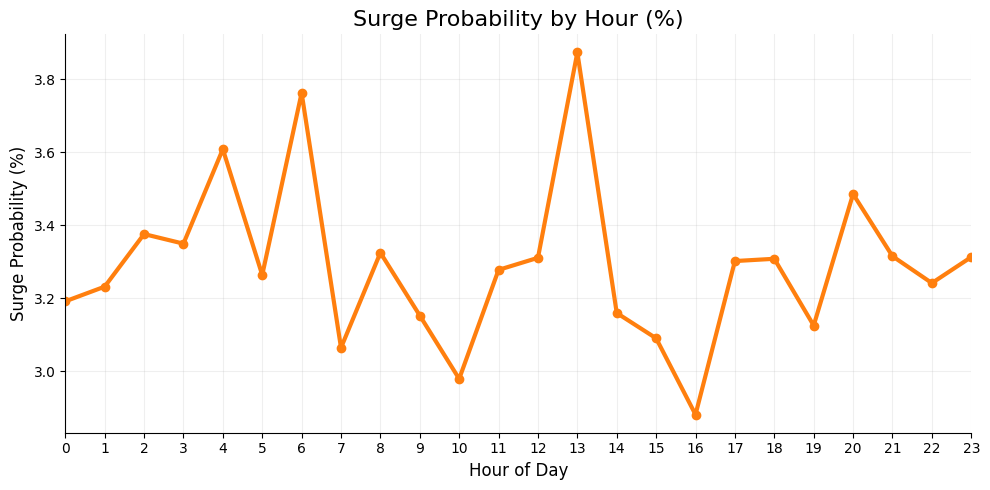

In [0]:
# Surge probability by hour (as %)
surge_prob_hour = (df['surge_multiplier'] > 1).groupby(df['hour']).mean() * 100

plt.figure(figsize=(10,5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

plt.plot(
    surge_prob_hour.index,
    surge_prob_hour.values,
    marker='o',
    linewidth=3,
    color='#ff7f0e'
)

plt.title('Surge Probability by Hour (%)', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Surge Probability (%)', fontsize=12)

plt.xlim(0, 23)
plt.xticks(range(24))
plt.grid(alpha=0.2)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.tick_params(colors='black')

plt.tight_layout()
plt.savefig("surge_by_hour.png", dpi=300, facecolor='white', bbox_inches='tight')
plt.show()


## 8) Rain vs No Rain — Surge Probability (%)

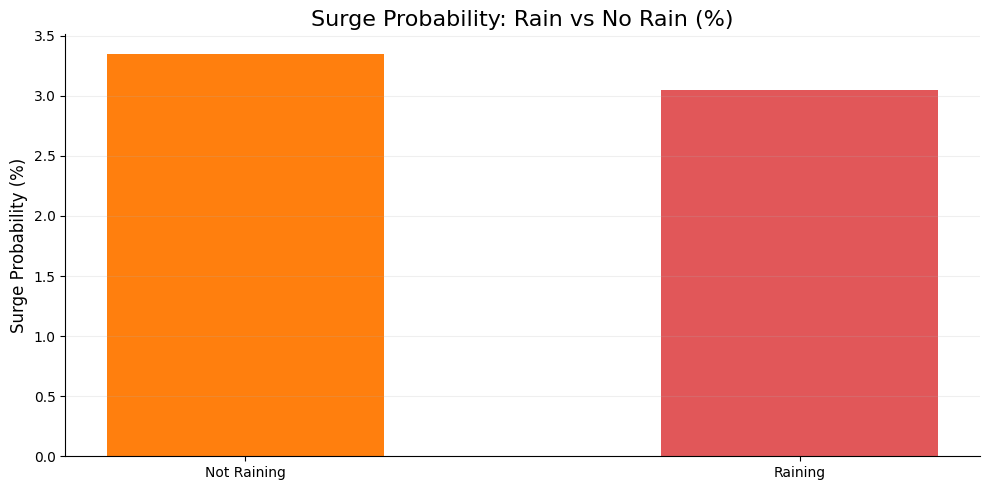

In [0]:
import matplotlib.pyplot as plt

surge_rain = (df['surge_multiplier'] > 1).groupby(df['is_Raining']).mean() * 100

labels = ['Not Raining', 'Raining']
values = surge_rain.values

# Match width with other charts
plt.figure(figsize=(10,5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

colors = ['#ff7f0e', '#e15759']

plt.bar(labels, values, width=0.5, color=colors)

plt.title('Surge Probability: Rain vs No Rain (%)', fontsize=16)
plt.ylabel('Surge Probability (%)', fontsize=12)

plt.grid(axis='y', alpha=0.2)

# Axis styling
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

plt.tight_layout()
plt.show()


## 9) Surge Probability by Vehicle Type


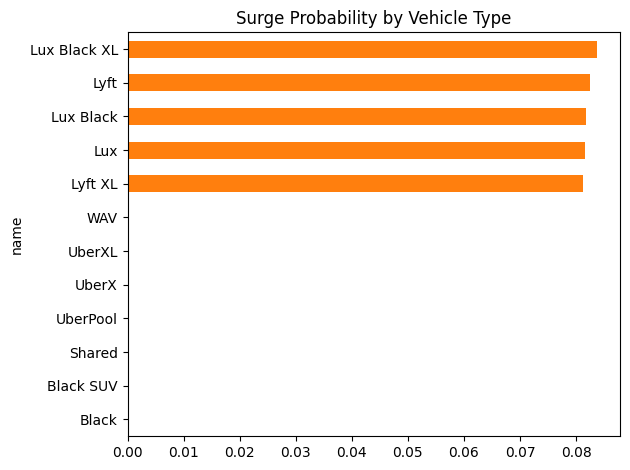

In [0]:
(df['surge_multiplier']>1).groupby(df['name']).mean().sort_values().plot(kind='barh',color='#ff7f0e')
plt.title("Surge Probability by Vehicle Type")
plt.tight_layout()
plt.show()

## 10) Average Price by Vehicle Type

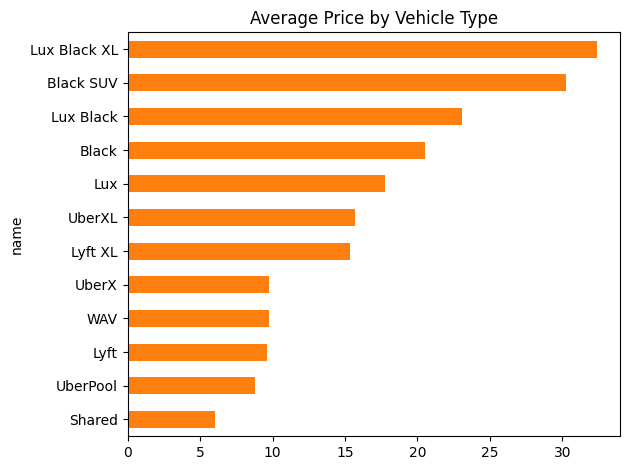

In [0]:
df.groupby('name')['price'].mean().sort_values().plot(kind='barh',color="#ff7f0e")
plt.title("Average Price by Vehicle Type")
plt.tight_layout()
plt.show()


## 11) Price by Distance Bucket

/home/spark-6ab178c0-80a5-46b5-bf71-f0/.ipykernel/3323/command-5032892718824713-295220755:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('distance_bucket')['price'].mean().sort_values().plot(kind='barh',color='#ff7f0e')


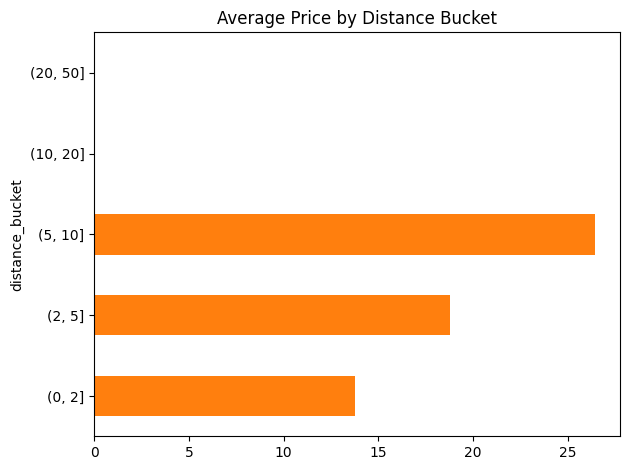

In [0]:
df['distance_bucket']=pd.cut(df['distance'],bins=[0,2,5,10,20,50])
df.groupby('distance_bucket')['price'].mean().sort_values().plot(kind='barh',color='#ff7f0e')
plt.title("Average Price by Distance Bucket")
plt.tight_layout()
plt.show()

## 12) Surge Probability by Temperature Bucket


/home/spark-6ab178c0-80a5-46b5-bf71-f0/.ipykernel/3323/command-5032892718824714-1799684905:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df['surge_multiplier'] > 1).groupby(df['temp_bucket']).mean().plot(kind='bar',color='#ff7f0e')


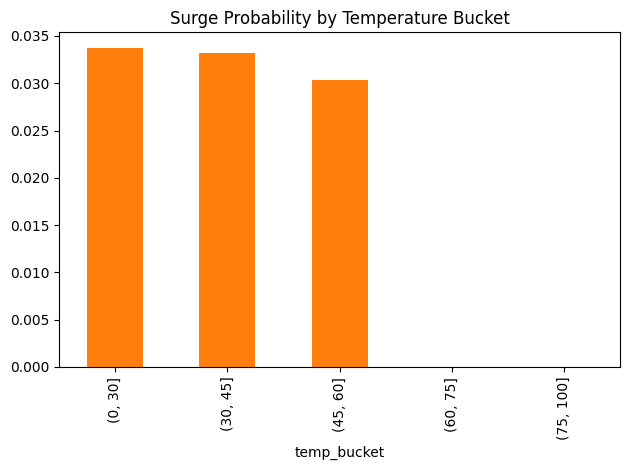

In [0]:
df['temp_bucket'] = pd.cut(df['temp'], bins=[0,30,45,60,75,100])
(df['surge_multiplier'] > 1).groupby(df['temp_bucket']).mean().plot(kind='bar',color='#ff7f0e')
plt.title("Surge Probability by Temperature Bucket")
plt.tight_layout()
plt.show()

## 13) Highest Surge Locations (Quick Ranking)

In [0]:
surge_by_source = (df['surge_multiplier'] > 1).groupby(df['source']).mean()
surge_by_source.sort_values(ascending=False).head(10)

source
Back Bay                   0.051987
Northeastern University    0.051022
Fenway                     0.050143
Theatre District           0.046525
Boston University          0.045579
Beacon Hill                0.039812
South Station              0.032259
Financial District         0.027975
North Station              0.017873
West End                   0.017142
Name: surge_multiplier, dtype: float64

In [0]:
g = df.groupby('source')

summary = g.agg(
    rides=('surge_multiplier', 'size'),
    surge_rate=('surge_multiplier', lambda s: (s > 1).mean()),
    avg_price=('price', 'mean')
).sort_values('surge_rate', ascending=False)

summary[summary['rides'] >= 5000].head(10)


,rides,surge_rate,avg_price
source,,,
Back Bay,97371,0.051987,16.081415
Northeastern University,97585,0.051022,17.873521
Fenway,96524,0.050143,18.301371
Theatre District,96723,0.046525,16.583142
Boston University,97237,0.045579,18.877608
Beacon Hill,97484,0.039812,15.702926
South Station,97181,0.032259,15.626707
Financial District,99697,0.027975,18.304045
North Station,96069,0.017873,16.414967


# Multivariate Analysis
Explore interactions between **location + time**, and **distance + vehicle type**.

In [0]:
df['is_surge']=df['surge_multiplier']>1
location_hour=(
  df.groupby(['source','hour'])['is_surge']
  .mean()
  .unstack()
)
location_hour.head()

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
source,,,,,,,,,,,,,,,,,,,,,,,,
Back Bay,0.050678,0.037645,0.062996,0.044922,0.055897,0.050056,0.058553,0.044485,0.044096,0.053357,0.047423,0.050232,0.053368,0.072834,0.035501,0.058228,0.047951,0.052207,0.057197,0.054761,0.056457,0.060202,0.052460,0.047420
Beacon Hill,0.033451,0.038991,0.048524,0.045518,0.031932,0.032670,0.050489,0.037736,0.026316,0.047505,0.045496,0.029093,0.038741,0.061868,0.039122,0.034594,0.028615,0.030219,0.035432,0.032394,0.056722,0.051171,0.032661,0.039280
Boston University,0.047526,0.029776,0.049068,0.050075,0.050710,0.035050,0.076577,0.031096,0.053473,0.037181,0.035443,0.056873,0.046184,0.044153,0.050321,0.033419,0.043378,0.065043,0.048359,0.045992,0.052883,0.038472,0.038771,0.039047
Fenway,0.052869,0.054099,0.044712,0.043613,0.056188,0.034132,0.039872,0.051583,0.032573,0.042180,0.065012,0.046282,0.058754,0.049746,0.053353,0.053997,0.037285,0.052009,0.048971,0.059725,0.037618,0.052804,0.044264,0.068762
Financial District,0.024836,0.020011,0.026100,0.020266,0.038153,0.042478,0.026932,0.025201,0.028337,0.029189,0.023805,0.028695,0.031215,0.033468,0.025683,0.024641,0.038969,0.019466,0.033087,0.031211,0.025641,0.033384,0.022182,0.029307


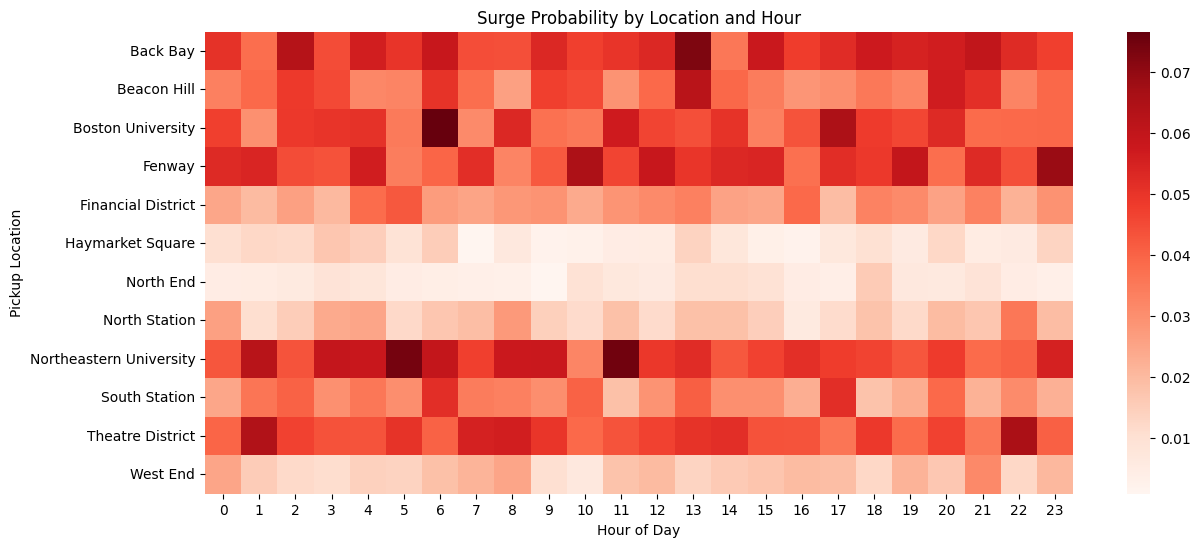

In [0]:
import seaborn as sns

plt.figure(figsize=(14,6))
sns.heatmap(location_hour, cmap='Reds')
plt.title('Surge Probability by Location and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Pickup Location')
plt.show()


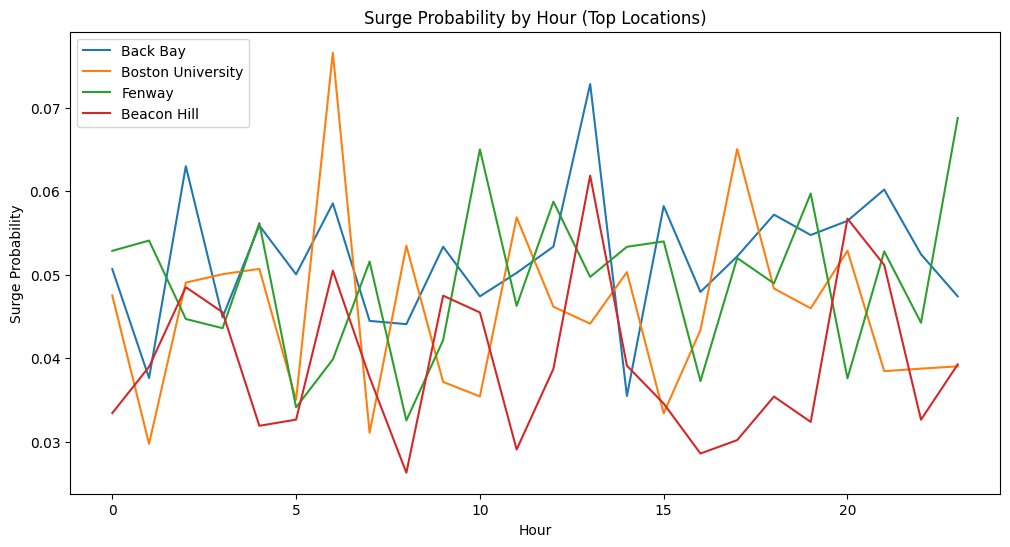

In [0]:
top_sources = ['Back Bay','Boston University','Fenway','Beacon Hill']

plt.figure(figsize=(12,6))
for src in top_sources:
    plt.plot(location_hour.columns, location_hour.loc[src], label=src)

plt.legend()
plt.title('Surge Probability by Hour (Top Locations)')
plt.xlabel('Hour')
plt.ylabel('Surge Probability')
plt.show()


In [0]:
df['distance_bucket'] = pd.cut(
    df['distance'],
    bins=[0,2,5,10,20],
    labels=['0-2','2-5','5-10','10+']
)

dist_vehicle = (
    df.groupby(['distance_bucket','name'])['price']
      .mean()
      .unstack()
)

dist_vehicle


/home/spark-6ab178c0-80a5-46b5-bf71-f0/.ipykernel/3323/command-8697482976625908-66934937:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['distance_bucket','name'])['price']


name,Black,Black SUV,Lux,Lux Black,Lux Black XL,Lyft,Lyft XL,Shared,UberPool,UberX,UberXL,WAV
distance_bucket,,,,,,,,,,,,
0-2,16.690490,26.935067,13.796037,18.379457,28.002163,7.810842,12.027741,4.731778,7.569009,8.275395,12.670653,8.272062
2-5,23.549050,32.843812,21.006935,26.814516,35.826384,11.084430,17.977961,7.063626,9.694449,10.961894,18.105322,10.949186
5-10,36.666754,46.384320,28.891552,38.010246,47.570478,14.195872,24.892074,9.444351,13.842174,15.997588,26.568486,15.870875
10+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


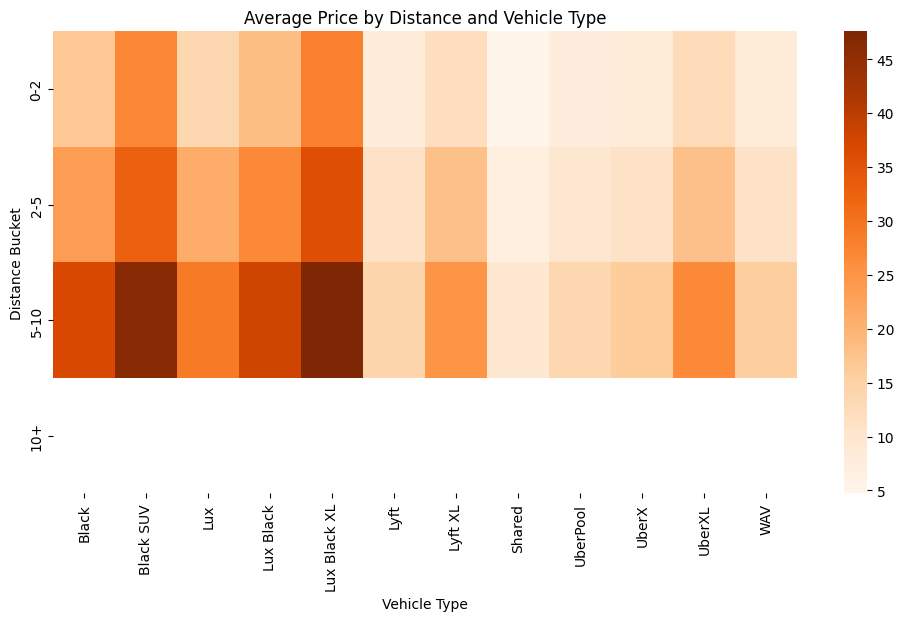

In [0]:
plt.figure(figsize=(12,6))
sns.heatmap(dist_vehicle, cmap='Oranges')
plt.title('Average Price by Distance and Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Distance Bucket')
plt.show()


# Feature Influence Check (Price Perspective)
**Important:** This section predicts **price** (not surge).  
It’s useful to understand price drivers, but it’s separate from “what drives surge”.



In [0]:
# Target = Price
# Features: distance, hour, temp + categorical: name, source, cab_type
# NOTE: You included surge_multiplier as a feature originally; that can dominate price prediction.

X=df[['distance','surge_multiplier','hour','temp','name','source','cab_type']]
Y=df['price']
X=pd.get_dummies(X,drop_first=True)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

df_sample = df.sample(n=80000, random_state=42)

X_sample = X.loc[df_sample.index]
y_sample = Y.loc[df_sample.index]

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42)

random_forest=RandomForestRegressor(n_estimators=50,max_depth=10,n_jobs=-1,random_state=42)
random_forest.fit(X_train,y_train)

importances=random_forest.feature_importances_
feature_imp=pd.Series(importances,index=X.columns).sort_values(ascending=False)
feature_imp.head(15)


name_Black SUV              0.271704
name_Lux Black XL           0.263102
distance                    0.144372
name_Lux Black              0.097575
name_Shared                 0.048230
name_UberX                  0.041079
name_Lyft                   0.037430
surge_multiplier            0.033799
name_WAV                    0.030546
name_UberPool               0.027977
temp                        0.001616
hour                        0.000841
source_North End            0.000362
source_Beacon Hill          0.000273
source_Boston University    0.000183
dtype: float64

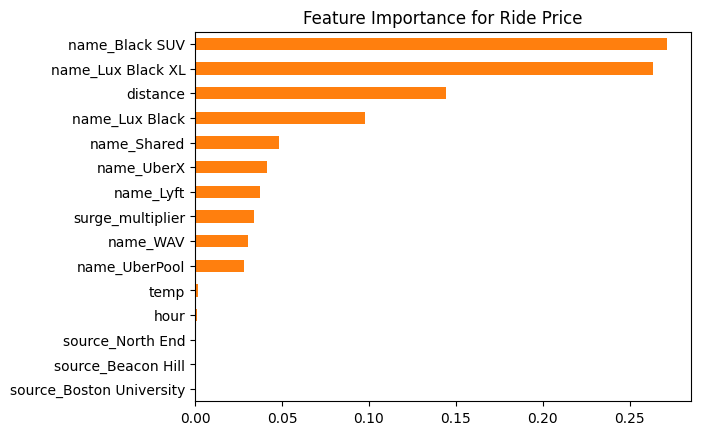

In [0]:
feature_imp.head(15).plot(kind='barh',color='#ff7f0e')
plt.title('Feature Importance for Ride Price')
plt.gca().invert_yaxis()
plt.show()


# Uber vs Lyft Comparison


In [0]:
df.groupby('cab_type')['price'].mean()

cab_type
Lyft    17.332895
Uber    15.811028
Name: price, dtype: float64

In [0]:
(df['surge_multiplier']>1).groupby(df['cab_type']).mean()

cab_type
Lyft    0.068441
Uber    0.000000
Name: surge_multiplier, dtype: float64

In [0]:
df.groupby(['cab_type','distance_bucket'])['price'].mean()


/home/spark-6ab178c0-80a5-46b5-bf71-f0/.ipykernel/3323/command-8697482976625919-3898940650:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['cab_type','distance_bucket'])['price'].mean()


cab_type  distance_bucket
Lyft      0-2                14.093997
          2-5                19.942493
          5-10               27.481680
          10+                      NaN
Uber      0-2                13.424496
          2-5                17.695396
          5-10               25.755464
          10+                      NaN
Name: price, dtype: float64

In [0]:
df.groupby('surge_multiplier')['price'].mean()


surge_multiplier
1.00    16.158915
1.25    23.802010
1.50    28.926294
1.75    33.489890
2.00    38.996894
2.50    30.734568
3.00    41.309524
Name: price, dtype: float64

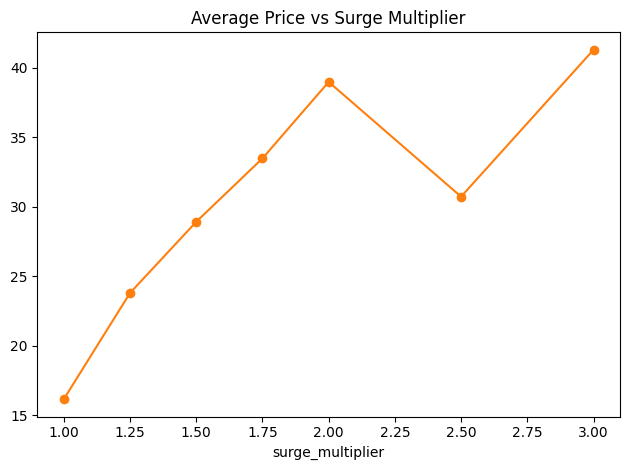

In [0]:
df.groupby('surge_multiplier')['price'].mean().plot(marker='o',color='#ff7f0e')
plt.title("Average Price vs Surge Multiplier")
plt.tight_layout()
plt.show()


# Location Cost vs Surge Risk Mapping

In [0]:
df.groupby('source')['surge_multiplier'].std()

df['price_per_mile'] = df['price'] / df['distance']
df.groupby('name')['price_per_mile'].mean()

avg_price_loc = df.groupby('source')['price'].mean()
surge_prob_loc = (df['surge_multiplier'] > 1).groupby(df['source']).mean()

risk_df = pd.concat([avg_price_loc, surge_prob_loc], axis=1)
risk_df.columns = ['avg_price', 'surge_prob']
risk_df.head()


,avg_price,surge_prob
source,,
Back Bay,16.081415,0.051987
Beacon Hill,15.702926,0.039812
Boston University,18.877608,0.045579
Fenway,18.301371,0.050143
Financial District,18.304045,0.027975


/home/spark-6ab178c0-80a5-46b5-bf71-f0/.ipykernel/3323/command-7181589314788801-3359192602:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (risk_df['avg_price'][i], risk_df['surge_prob'][i]),


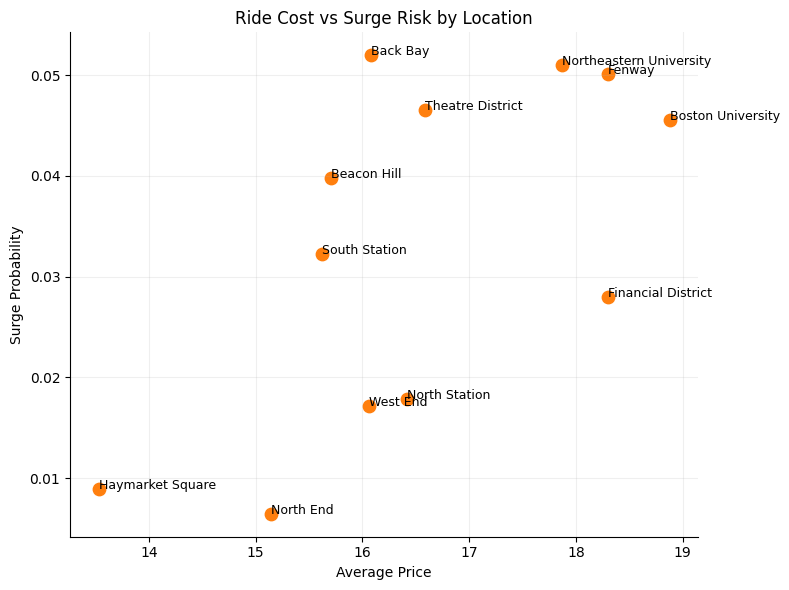

In [0]:
plt.figure(figsize=(8,6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

plt.scatter(
    risk_df['avg_price'],
    risk_df['surge_prob'],
    color='#ff7f0e',
    s=80
)

for i, txt in enumerate(risk_df.index):
    plt.annotate(
        txt,
        (risk_df['avg_price'][i], risk_df['surge_prob'][i]),
        fontsize=9
    )

plt.xlabel('Average Price')
plt.ylabel('Surge Probability')
plt.title('Ride Cost vs Surge Risk by Location')

plt.grid(alpha=0.2)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [0]:
## Surge Probability by Weekday (%)

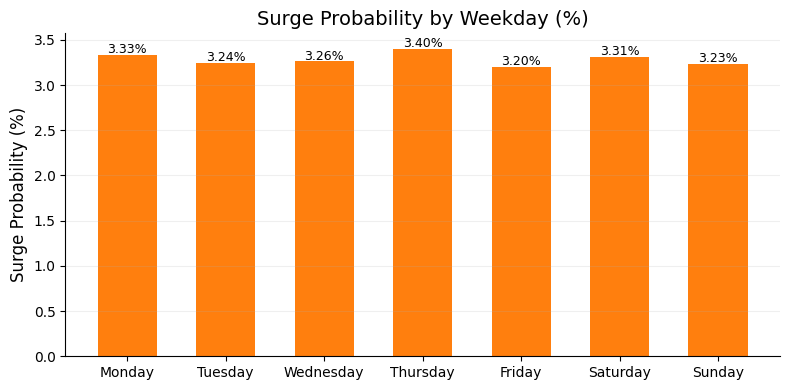

In [0]:
surge_weekday = (df['surge_multiplier'] > 1).groupby(df['weekday']).mean() * 100

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
surge_weekday = surge_weekday.reindex(order)

plt.figure(figsize=(8,4), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

for i, v in enumerate(surge_weekday.values):
    plt.text(i, v + 0.02, f"{v:.2f}%", ha='center', fontsize=9)

plt.bar(
    surge_weekday.index,
    surge_weekday.values,
    color='#ff7f0e',
    width=0.6
)

plt.title('Surge Probability by Weekday (%)', fontsize=14)
plt.ylabel('Surge Probability (%)', fontsize=12)
plt.grid(axis='y', alpha=0.2)

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

plt.tight_layout()
plt.savefig("surge_weekday.png", dpi=300, facecolor='white', bbox_inches='tight')
plt.show()


# Key Findings
- Surge events are **rare (~3–4% of rides)** in this dataset
- **Hour of day** shows modest variation (early afternoon slightly higher)
- **Rain alone** shows minimal effect on surge likelihood
- **Weekday patterns** are relatively stable

## Limitations
- ~3 weeks of data
- Single city
- No explicit event/holiday indicators

## Future Work
- Longer time range / multi-city
- Add event features
- Feature importance for **surge classification** (predicting `is_surge`)
